In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8")

dataset loading

In [2]:
DATA_PATH = "../data/raw"

print("Files in raw data folder:")
for f in os.listdir(DATA_PATH):
    print(f)

Files in raw data folder:
adj_mx_bay.pkl
pems-bay-meta.h5
pems-bay.h5


In [5]:
import h5py

file_path = os.path.join(DATA_PATH, "pems-bay.h5")

with h5py.File(file_path, "r") as f:
    print(list(f.keys()))

['speed']


In [7]:
with h5py.File(file_path, "r") as f:
    speed_group = f["speed"]
    print("Type:", type(speed_group))
    print("Keys inside 'speed':")
    print(list(speed_group.keys()))

Type: <class 'h5py._hl.group.Group'>
Keys inside 'speed':
['axis0', 'axis1', 'block0_items', 'block0_values']


In [8]:
with h5py.File(file_path, "r") as f:
    speed_data = f["speed"]["block0_values"][:]

speed_data.shape

(52116, 325)

speed analysis

In [9]:
speed_df = pd.DataFrame(speed_data)
speed_df.head()

,0,1,2,3,4,5,6,7,8,9,...,315,316,317,318,319,320,321,322,323,324
0,71.4,67.8,70.5,67.4,68.8,66.6,66.8,68.0,66.8,69.0,...,68.8,67.9,68.8,68.0,69.2,68.9,70.4,68.8,71.1,68.0
1,71.6,67.5,70.6,67.5,68.7,66.6,66.8,67.8,66.5,68.2,...,68.4,67.3,68.4,67.6,70.4,68.8,70.1,68.4,70.8,67.4
2,71.6,67.6,70.2,67.4,68.7,66.1,66.8,67.8,66.2,67.8,...,68.4,67.4,68.4,67.5,70.2,68.3,69.8,68.4,70.5,67.9
3,71.1,67.5,70.3,68.0,68.5,66.7,66.6,67.7,65.9,67.8,...,68.5,67.5,68.5,67.5,70.4,68.7,70.2,68.4,70.8,67.6
4,71.7,67.8,70.2,68.1,68.4,66.9,66.1,67.7,66.1,67.8,...,68.5,67.7,68.5,67.4,69.6,69.1,70.0,68.4,71.0,67.9


In [10]:
speed_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,315,316,317,318,319,320,321,322,323,324
count,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,...,52116.000000,52116.00000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000
mean,67.568557,59.019079,59.138577,62.137407,61.195873,63.314788,58.777483,63.565579,62.069533,57.726957,...,65.795827,63.61541,63.815680,60.647717,66.148728,57.203082,67.566198,64.604361,67.351650,64.328245
std,8.119154,13.250178,11.658612,8.617881,11.019177,11.159615,13.078931,8.434674,10.557263,18.113331,...,5.645500,6.42068,8.381049,4.622528,4.511122,10.932359,5.992427,4.753887,7.060815,8.455986
min,0.000000,11.000000,3.400000,0.000000,7.400000,0.000000,0.000000,0.000000,0.000000,5.300000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,67.300000,62.200000,55.800000,59.400000,57.500000,65.000000,58.400000,64.200000,63.300000,61.300000,...,64.700000,63.80000,63.700000,60.000000,63.700000,57.800000,67.200000,62.900000,67.000000,64.600000
50%,70.300000,64.000000,62.700000,66.200000,63.500000,66.500000,63.700000,66.400000,65.500000,65.500000,...,67.500000,65.10000,66.100000,61.600000,66.700000,60.900000,69.400000,66.100000,69.000000,66.400000
75%,71.300000,65.100000,66.600000,67.700000,69.500000,67.500000,66.300000,67.500000,67.000000,67.400000,...,68.500000,66.40000,67.300000,62.600000,69.500000,62.600000,70.400000,67.900000,70.400000,67.700000
max,80.400000,71.600000,77.700000,76.900000,78.900000,78.700000,78.200000,80.000000,75.400000,72.300000,...,78.600000,73.70000,78.900000,69.900000,76.800000,79.900000,79.900000,72.500000,80.400000,74.300000


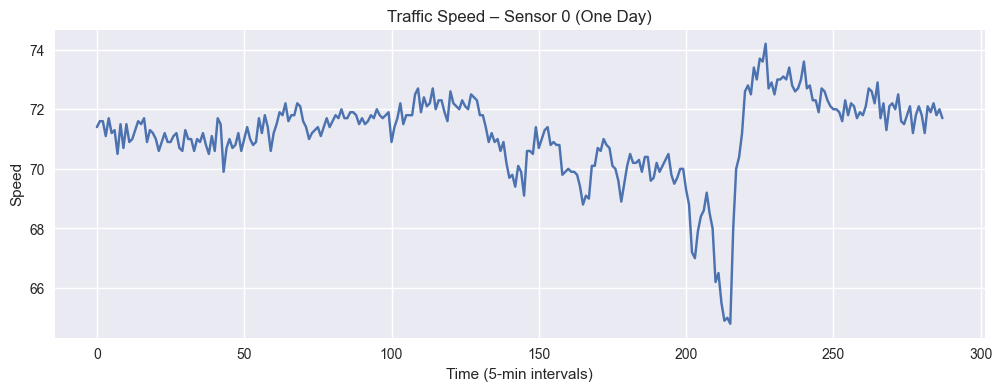

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(speed_df.iloc[:288, 0])
plt.title("Traffic Speed – Sensor 0 (One Day)")
plt.xlabel("Time (5-min intervals)")
plt.ylabel("Speed")
plt.show()

### Observations
- Number of sensors: *325*
- Time interval: *5 min*
- Type of values recorded:
- Total time steps: *52116*

### Speed Data Description
- Rows represent time steps (5-minute intervals)
- Columns represent traffic sensors
- Values represent average traffic speed

congestion analysis

In [12]:
# Define congestion thresholds (can be tuned later)
LOW_THRESHOLD = 65
HIGH_THRESHOLD = 55

def congestion_level(speed):
    if speed >= LOW_THRESHOLD:
        return "Low"
    elif speed >= HIGH_THRESHOLD:
        return "Medium"
    else:
        return "High"

In [14]:
sensor_0 = speed_df.iloc[:, 0]

congestion_labels = sensor_0.apply(congestion_level)
congestion_labels.value_counts()

0
Low       43277
Medium     6313
High       2526
Name: count, dtype: int64

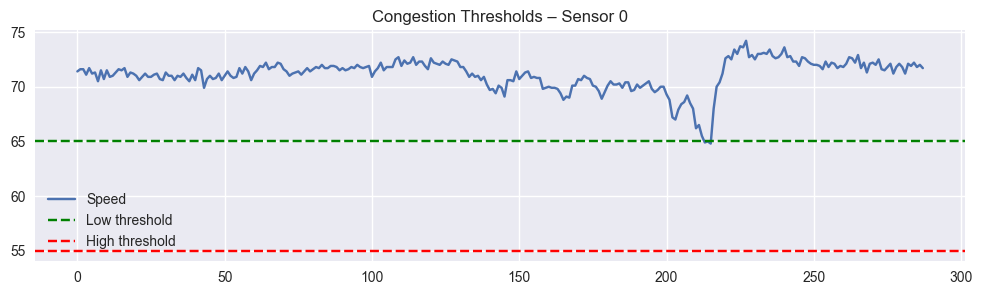

In [15]:
plt.figure(figsize=(12, 3))
plt.plot(sensor_0[:288], label="Speed")
plt.axhline(LOW_THRESHOLD, color="green", linestyle="--", label="Low threshold")
plt.axhline(HIGH_THRESHOLD, color="red", linestyle="--", label="High threshold")
plt.legend()
plt.title("Congestion Thresholds – Sensor 0")
plt.show()

peak hour detection

In [16]:
time_index = pd.date_range(
    start="00:00",
    periods=288,
    freq="5min"
)

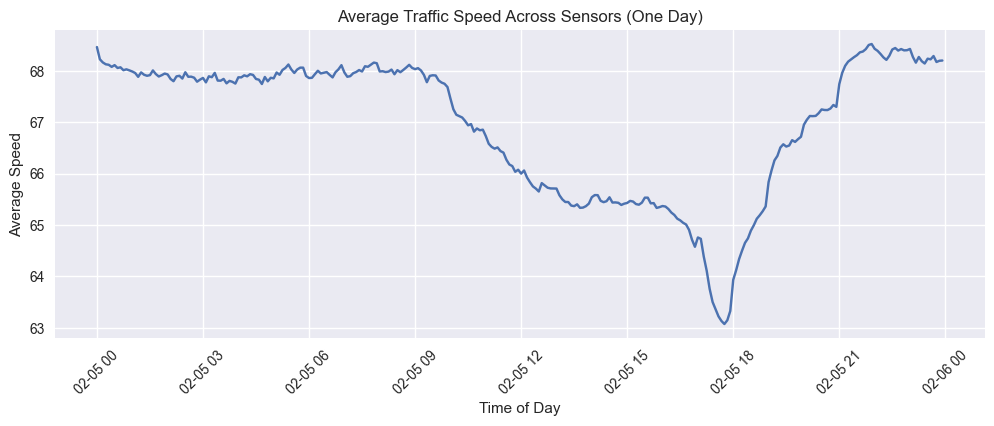

In [17]:
daily_speed = speed_df.iloc[:288, :].mean(axis=1)

plt.figure(figsize=(12, 4))
plt.plot(time_index, daily_speed)
plt.title("Average Traffic Speed Across Sensors (One Day)")
plt.xlabel("Time of Day")
plt.ylabel("Average Speed")
plt.xticks(rotation=45)
plt.show()

In [18]:
daily_congestion = daily_speed.apply(congestion_level)

daily_congestion.value_counts()

Low       265
Medium     23
Name: count, dtype: int64

preparation for lstm

In [19]:
sensor_series = speed_df.iloc[:, 0].values

In [20]:
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [21]:
SEQ_LENGTH = 12

X, y = create_sequences(sensor_series, SEQ_LENGTH)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (52104, 12)
y shape: (52104,)


In [22]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

normalize the data

In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler = MinMaxScaler()

# reshape for scaler
X_train_scaled = scaler.fit_transform(
    X_train.reshape(-1, 1)
).reshape(X_train.shape)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, 1)
).reshape(X_test.shape)

y_train_scaled = scaler.transform(y_train.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

In [25]:
print("Scaled X min:", X_train_scaled.min())
print("Scaled X max:", X_train_scaled.max())

Scaled X min: 0.0
Scaled X max: 1.0


reshape data

In [26]:
X_train_lstm = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_lstm = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

X_train_lstm.shape, X_test_lstm.shape

((41683, 12, 1), (10421, 12, 1))

BUILDING LSTM MODEL

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        activation="tanh",
        input_shape=(X_train_lstm.shape[1], 1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train_scaled,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.6149e-04 - val_loss: 6.3320e-04
Epoch 2/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.5391e-04 - val_loss: 5.8967e-04
Epoch 3/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.4853e-04 - val_loss: 5.5441e-04
Epoch 4/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.3288e-04 - val_loss: 6.6928e-04
Epoch 5/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 4.2808e-04 - val_loss: 5.5004e-04
Epoch 6/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.1693e-04 - val_loss: 5.2155e-04
Epoch 7/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.0634e-04 - val_loss: 5.4772e-04
Epoch 8/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.0727e-04 - val_loss: 5.3059e-04
Epoch 9/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.9985e-04 - val_loss: 5.3930e-04
Epoch 10/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.9517e-04 - val_loss: 6.1206e-04
Epoch 11/20
522/522 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss

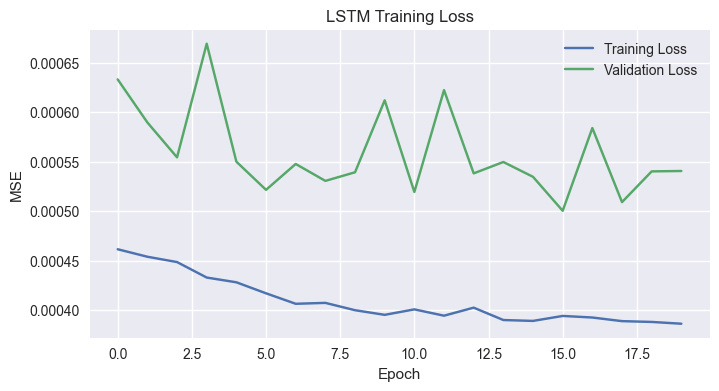

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

Prediction & Evaluation

In [34]:
y_pred_scaled = model.predict(X_test_lstm)

326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [35]:
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_scaled)

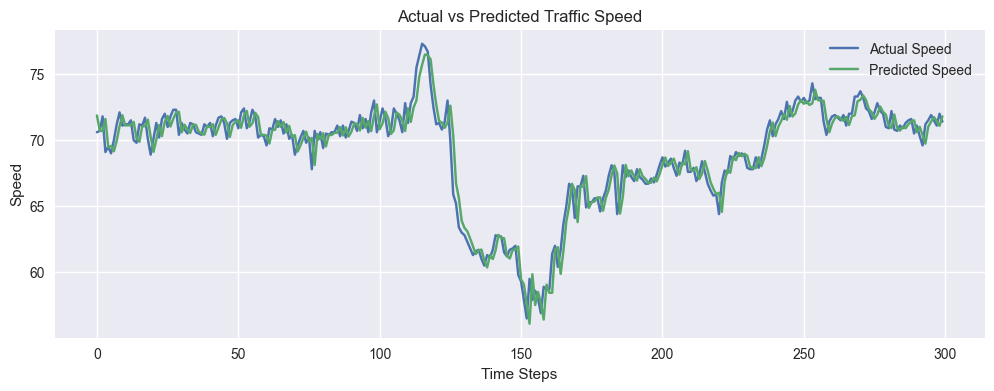

In [36]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:300], label="Actual Speed")
plt.plot(y_pred[:300], label="Predicted Speed")
plt.legend()
plt.title("Actual vs Predicted Traffic Speed")
plt.xlabel("Time Steps")
plt.ylabel("Speed")
plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.9017343139799437
RMSE: 1.7840111840405326
